# 03 · Visualizações — Desertos de Saúde (SP)
**Objetivo:** cinco gráficos para um gestor público (público não técnico). Cada título traz a conclusão e cada gráfico é salvo em PNG.

**Entradas:** `analise_output/municipios-sp-analise.geojson` e `etl_output/cnes-sp.geojson`.
**Saídas:** pasta `visualizacoes/` (5 imagens).

| # | Gráfico | Mensagem |
|---|---------|----------|
| 1 | Mapa de leitos por 10 mil hab. | Onde faltam leitos de internação |
| 2 | Mapa de pontos | Onde estão hospitais e urgências (e os desertos) |
| 3 | Barras | Cidades grandes com pior cobertura |
| 4 | Dispersão | Riqueza não garante mais leitos |
| 5 | Mapa de calor | A região de São Paulo tem menos serviços por habitante |

**Definição de deserto usada aqui:** município sem pronto-socorro/UPA **e** sem hospital.

## Preparação — dados, cores e funções de apoio

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import geopandas as gpd, pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from scipy.stats import spearmanr

BASE = "/content/drive/MyDrive/Trabalho UBD"
OUT = f"{BASE}/visualizacoes"
os.makedirs(OUT, exist_ok=True)

mun = gpd.read_file(f"{BASE}/analise_output/municipios-sp-analise.geojson")
pts = gpd.read_file(f"{BASE}/etl_output/cnes-sp.geojson")

# PIB per capita (int64 evita estouro ao multiplicar por 1000)
mun["pib_per_capita"] = mun["pib_mil_reais"].astype("int64") * 1000 / mun["populacao"]
# Deserto = sem pronto-socorro/UPA e sem hospital (mesma definição do 02)
mun["deserto_estrito"] = mun["deserto_urgencia"] & (mun["n_hospitais"] == 0)

# Totais usados nos textos dos gráficos
TOT_POP = mun["populacao"].sum()
MEDIA_EST = mun["leitos"].sum() / TOT_POP * 10_000

# Estilo geral
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
COR_TITULO, COR_SUB = "#1F3A34", "#5A5A5A"

def titulo(ax, principal, sub=None, size=14):
    """Título em negrito (a conclusão) + subtítulo com o contexto."""
    ax.set_title(principal, loc="left", fontsize=size, weight="bold", color=COR_TITULO, pad=26 if sub else 10)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=10.5, color=COR_SUB, va="bottom")

def br(x, n=1):
    """Número no formato brasileiro (vírgula decimal)."""
    return f"{x:,.{n}f}".replace(",", "X").replace(".", ",").replace("X", ".")

def fig_mapa(w=11):
    """Figura com a proporção correta do mapa de SP."""
    b = mun.total_bounds
    return plt.subplots(figsize=(w, w * (b[3] - b[1]) / (b[2] - b[0]) + 0.4))

print(len(mun), "municípios |", len(pts), "estabelecimentos |", int(mun["deserto_estrito"].sum()), "desertos")

Mounted at /content/drive
645 municípios | 135647 estabelecimentos | 216 desertos


## 1. Mapa — Municípios sem nenhum leito de internação

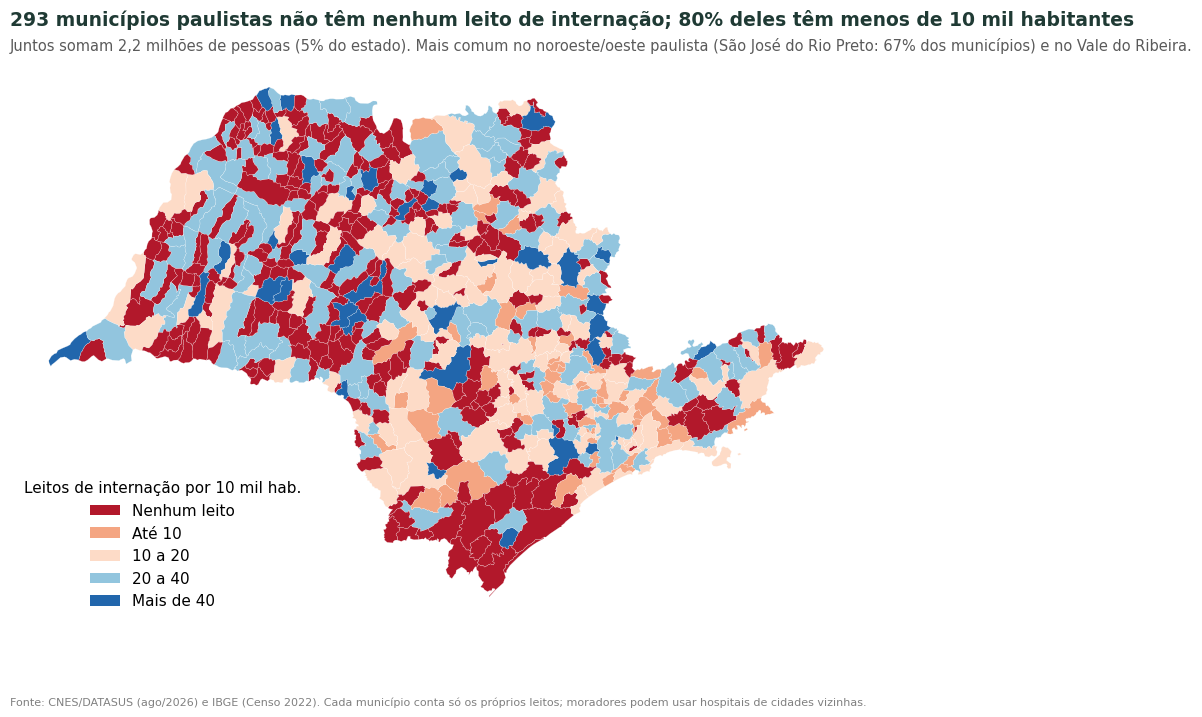

In [ ]:
# Faixas de leitos por 10 mil hab. e cores (vermelho = pior)
rotulos = ["Nenhum leito", "Até 10", "10 a 20", "20 a 40", "Mais de 40"]
cores = ["#B2182B", "#F4A582", "#FDDBC7", "#92C5DE", "#2166AC"]
cat = pd.cut(mun["leitos_10k"], [0, 0.001, 10, 20, 40, 1000], labels=rotulos, right=False, include_lowest=True)

# Números para o título
zero = mun[mun["leitos"] == 0]
n0, pop0 = len(zero), zero["populacao"].sum()
pct_peq = (zero["populacao"] < 10_000).mean()          # % deles com menos de 10 mil hab.
pior = mun.groupby("regiao")["leitos"].agg(lambda x: (x == 0).mean()).idxmax()
pct_pior = (mun[mun["regiao"] == pior]["leitos"] == 0).mean()

# Desenho do mapa
fig, ax = fig_mapa()
mun.assign(cat=cat).plot(column="cat", ax=ax, categorical=True, legend=False,
                         cmap=ListedColormap(cores), edgecolor="white", linewidth=0.15)
ax.set_axis_off()
ax.legend(handles=[Patch(facecolor=c, label=r) for c, r in zip(cores, rotulos)],
          title="Leitos de internação por 10 mil hab.", loc="lower left", frameon=False)
titulo(ax, f"{n0} municípios paulistas não têm nenhum leito de internação; {pct_peq:.0%} deles têm menos de 10 mil habitantes",
       f"Juntos somam {br(pop0/1e6)} milhões de pessoas ({pop0/TOT_POP:.0%} do estado). Mais comum no noroeste/oeste paulista "
       f"({pior}: {pct_pior:.0%} dos municípios) e no Vale do Ribeira.", size=13.5)
fig.text(0.125, 0.02, "Fonte: CNES/DATASUS (ago/2026) e IBGE (Censo 2022). Cada município conta só os próprios leitos; moradores podem usar hospitais de cidades vizinhas.", fontsize=8, color="gray")
fig.savefig(f"{OUT}/1_mapa_leitos.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Mapa de pontos — Hospitais e unidades de urgência

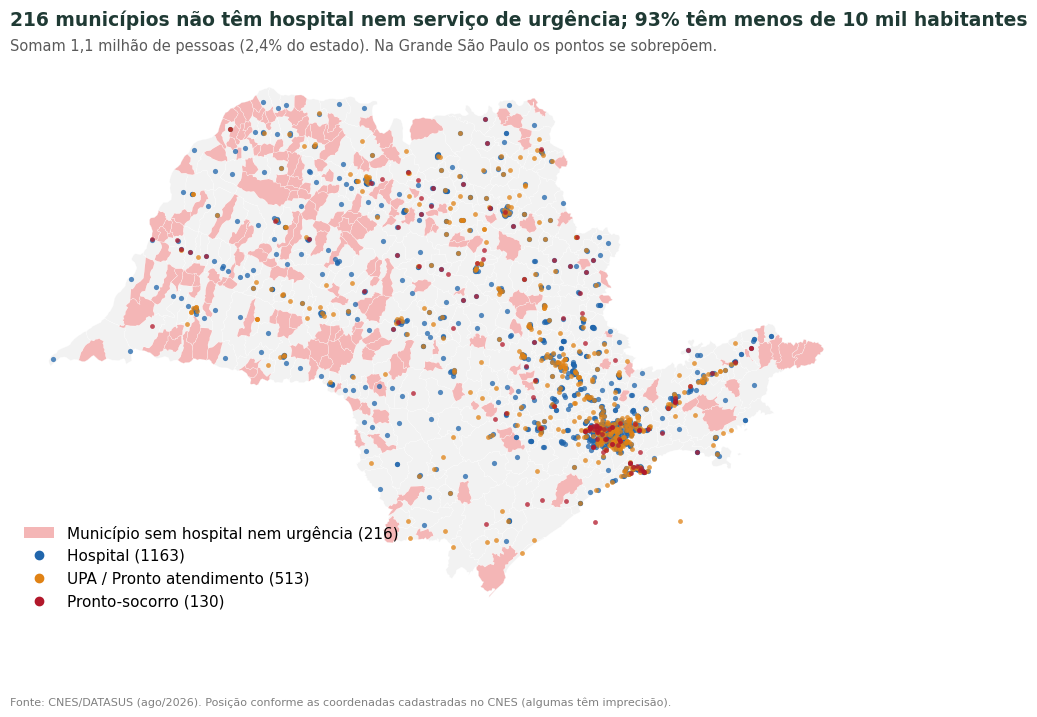

In [ ]:
fig, ax = fig_mapa()
mun.plot(ax=ax, color="#F2F2F2", edgecolor="white", linewidth=0.2)                             # base cinza
mun[mun["deserto_estrito"]].plot(ax=ax, color="#F4B6B6", edgecolor="white", linewidth=0.2)     # desertos em rosa

# Um tipo de estabelecimento por cor
estilos = {"Hospital": ("#2166AC", 14), "UPA / Pronto atendimento": ("#E08214", 12), "Pronto-socorro": ("#B2182B", 12)}
for tipo, (cor, tam) in estilos.items():
    sub = pts[pts["categoria"] == tipo]
    ax.scatter(sub.geometry.x, sub.geometry.y, s=tam, c=cor, alpha=0.75, linewidths=0)
ax.set_axis_off()

de = mun[mun["deserto_estrito"]]
handles = [Patch(facecolor="#F4B6B6", label=f"Município sem hospital nem urgência ({len(de)})")]
handles += [Line2D([], [], marker="o", ls="", color=cor, label=f"{tipo} ({(pts['categoria'] == tipo).sum()})")
            for tipo, (cor, _) in estilos.items()]
ax.legend(handles=handles, loc="lower left", frameon=False)
titulo(ax, f"{len(de)} municípios não têm hospital nem serviço de urgência; {(de['populacao'] < 10_000).mean():.0%} têm menos de 10 mil habitantes",
       f"Somam {br(de['populacao'].sum()/1e6)} milhão de pessoas ({br(de['populacao'].sum()/TOT_POP*100)}% do estado). Na Grande São Paulo os pontos se sobrepõem.", size=13.5)
fig.text(0.125, 0.02, "Fonte: CNES/DATASUS (ago/2026). Posição conforme as coordenadas cadastradas no CNES (algumas têm imprecisão).", fontsize=8, color="gray")
fig.savefig(f"{OUT}/2_mapa_pontos.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Barras — Cidades com mais de 20 mil habitantes e pior cobertura

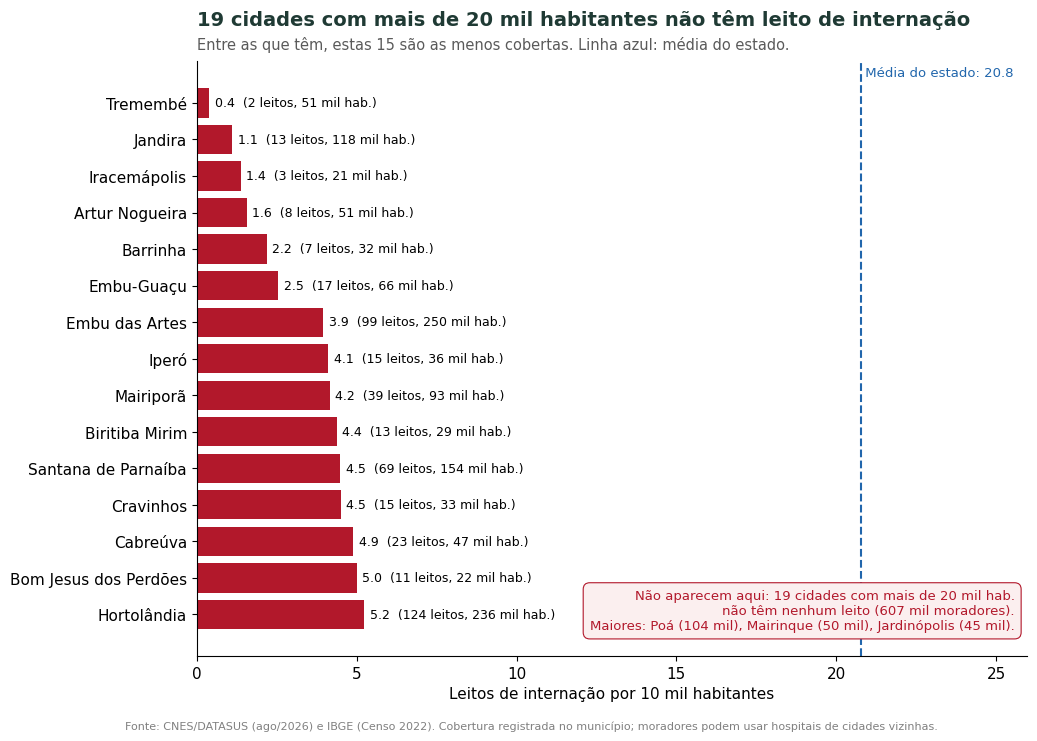

In [ ]:
N, POP_MIN = 15, 20_000
grandes = mun[mun["populacao"] >= POP_MIN]
zero_g = grandes[grandes["leitos"] == 0]                                   # cidades grandes sem leito (barra seria 0)
d = grandes[grandes["leitos"] > 0].nsmallest(N, "leitos_10k").sort_values("leitos_10k", ascending=False)

fig, ax = plt.subplots(figsize=(10.5, 7.4))
barras = ax.barh(d["municipio"], d["leitos_10k"], color="#B2182B")
ax.bar_label(barras, labels=[f"{v:.1f}  ({int(l)} leitos, {int(p/1000)} mil hab.)"
                             for v, l, p in zip(d["leitos_10k"], d["leitos"], d["populacao"])], padding=4, fontsize=9)

# Linha da média do estado
ax.axvline(MEDIA_EST, color="#2166AC", ls="--", lw=1.5)
ax.text(MEDIA_EST, len(d) - 0.35, f" Média do estado: {MEDIA_EST:.1f}", color="#2166AC", fontsize=9.5, va="bottom")
ax.set_xlabel("Leitos de internação por 10 mil habitantes")
ax.set_xlim(0, MEDIA_EST * 1.25)

# Caixa com as cidades grandes que ficaram de fora (zero leitos)
maiores = zero_g.sort_values("populacao", ascending=False).head(3)
lista = ", ".join(f"{m} ({p/1000:.0f} mil)" for m, p in zip(maiores["municipio"], maiores["populacao"]))
ax.text(0.985, 0.04, f"Não aparecem aqui: {len(zero_g)} cidades com mais de 20 mil hab.\n"
        f"não têm nenhum leito ({zero_g['populacao'].sum()/1000:.0f} mil moradores).\nMaiores: {lista}.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="#B2182B", zorder=5,
        bbox=dict(boxstyle="round,pad=0.5", fc="#FBEFEF", ec="#B2182B", lw=0.8))

titulo(ax, f"{len(zero_g)} cidades com mais de 20 mil habitantes não têm leito de internação",
       f"Entre as que têm, estas {N} são as menos cobertas. Linha azul: média do estado.")
fig.text(0.125, 0.005, "Fonte: CNES/DATASUS (ago/2026) e IBGE (Censo 2022). Cobertura registrada no município; moradores podem usar hospitais de cidades vizinhas.", fontsize=8, color="gray")
plt.tight_layout(rect=(0, 0.02, 1, 1))
fig.savefig(f"{OUT}/3_barras_piores.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Dispersão — PIB per capita × leitos
A correlação é calculada só com cidades de **20 mil+ habitantes**, porque municípios muito pequenos distorcem a razão leitos/habitantes. No 02 o mesmo cálculo aparece para todos os recortes.

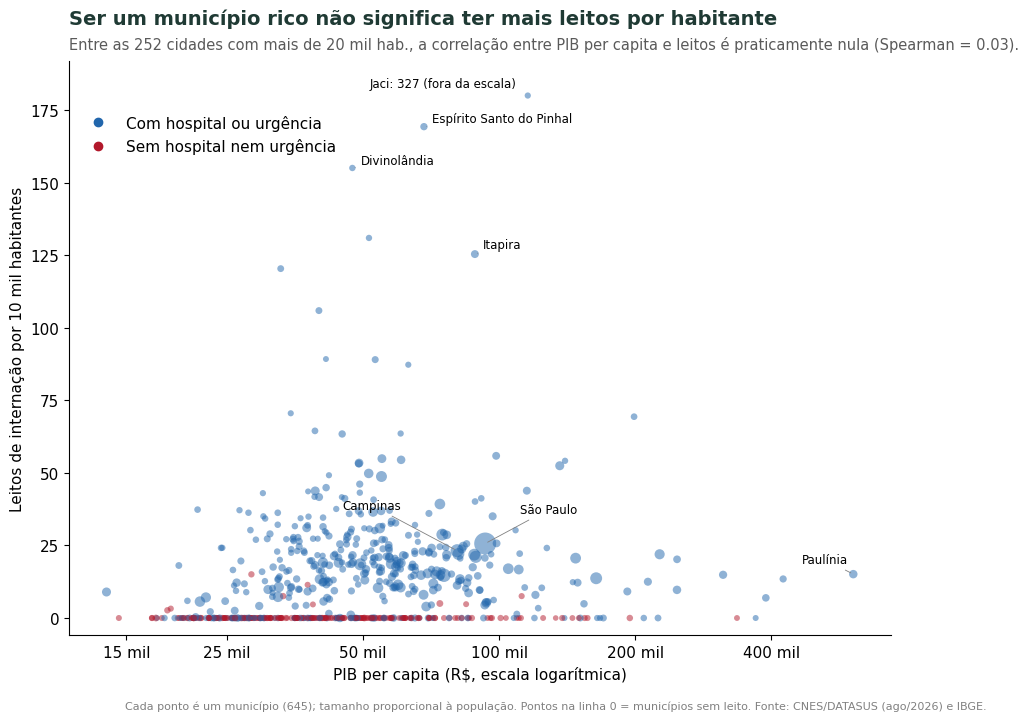

In [ ]:
d = mun.dropna(subset=["pib_per_capita", "leitos_10k"]).copy()
g20 = d[d["populacao"] >= 20_000]
rho, _ = spearmanr(g20["pib_per_capita"], g20["leitos_10k"])
forca = "praticamente nula" if abs(rho) < 0.1 else "fraca"
YMAX = 180                                                   # valores acima disso são cortados no eixo

fig, ax = plt.subplots(figsize=(10.5, 7.2))
ax.scatter(d["pib_per_capita"], d["leitos_10k"].clip(upper=YMAX), s=14 + np.sqrt(d["populacao"]) * 0.07,
           c=np.where(d["deserto_estrito"], "#B2182B", "#2166AC"), alpha=0.5, linewidths=0)
ax.set_xscale("log")
ax.set_ylim(-6, YMAX + 12)
ax.set_xlabel("PIB per capita (R$, escala logarítmica)")
ax.set_ylabel("Leitos de internação por 10 mil habitantes")
ax.set_xticks([15_000, 25_000, 50_000, 100_000, 200_000, 400_000])
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1000:.0f} mil")
ax.xaxis.set_minor_locator(plt.NullLocator())

# Nomes de alguns municípios (deslocamento x, y em pontos) com uma linha ligando ao ponto
destaques = {"São Paulo": (25, 22, "left"), "Campinas": (-40, 30, "right"), "Paulínia": (-4, 8, "right"),
           "Itapira": (6, 4, "left"), "Divinolândia": (6, 3, "left"), "Espírito Santo do Pinhal": (6, 3, "left")}
seta = dict(arrowstyle="-", color="gray", lw=0.6)
for _, r in d[d["municipio"].isin(destaques)].iterrows():
    dx, dy, ha = destaques[r["municipio"]]
    ax.annotate(r["municipio"], (r["pib_per_capita"], r["leitos_10k"]), xytext=(dx, dy),
                textcoords="offset points", fontsize=8.5, ha=ha, arrowprops=seta)

# Pontos acima do limite do eixo (ex.: Jaci)
for _, r in d[d["leitos_10k"] > YMAX].iterrows():
    ax.annotate(f"{r['municipio']}: {r['leitos_10k']:.0f} (fora da escala)", (r["pib_per_capita"], YMAX),
                xytext=(-8, 4), textcoords="offset points", fontsize=8.5, ha="right", va="bottom")

ax.legend(handles=[Line2D([], [], marker="o", ls="", color="#2166AC", label="Com hospital ou urgência"),
                   Line2D([], [], marker="o", ls="", color="#B2182B", label="Sem hospital nem urgência")],
          loc="upper left", frameon=False, bbox_to_anchor=(0.0, 0.93))
titulo(ax, "Ser um município rico não significa ter mais leitos por habitante",
       f"Entre as {len(g20)} cidades com mais de 20 mil hab., a correlação entre PIB per capita e leitos é {forca} (Spearman = {rho:.2f}).")
fig.text(0.125, 0.005, f"Cada ponto é um município ({len(d)}); tamanho proporcional à população. Pontos na linha 0 = municípios sem leito. Fonte: CNES/DATASUS (ago/2026) e IBGE.", fontsize=8, color="gray")
plt.tight_layout(rect=(0, 0.02, 1, 1))
fig.savefig(f"{OUT}/4_scatter_pib_leitos.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Mapa de calor — Serviços por região

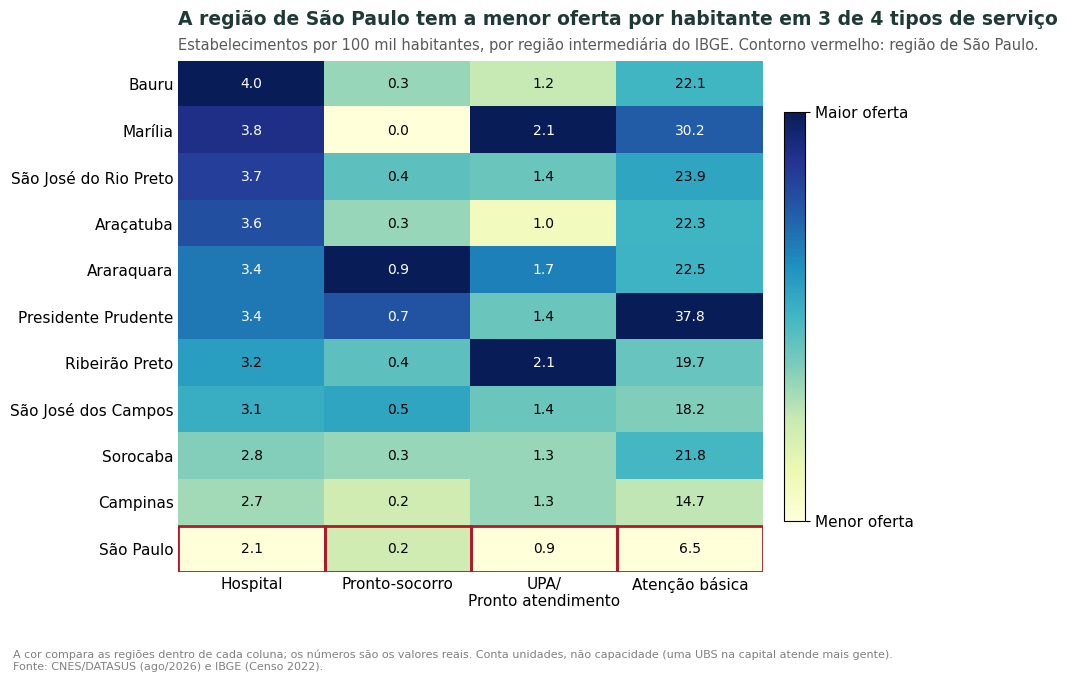

In [ ]:
# Junta cada estabelecimento à sua região
j = pts.merge(mun[["cod6", "regiao"]], left_on="cod6_geo", right_on="cod6", how="left")
tipos = ["Hospital", "Pronto-socorro", "UPA / Pronto atendimento", "Atenção básica"]

# Estabelecimentos por 100 mil habitantes, por região e tipo
tab = (j[j["categoria"].isin(tipos)].groupby(["regiao", "categoria"]).size().unstack(fill_value=0)
         .reindex(columns=tipos, fill_value=0))
pop_reg = mun.groupby("regiao")["populacao"].sum()
tab = tab.div(pop_reg, axis=0).mul(100_000).round(1).sort_values("Hospital", ascending=False)

# A cor compara as regiões dentro de cada coluna; os números são os valores reais
norm = (tab - tab.min()) / (tab.max() - tab.min()).replace(0, 1)

fig, ax = plt.subplots(figsize=(10, 6.8))
im = ax.imshow(norm.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(tab.columns)))
ax.set_xticklabels([c.replace(" / ", "/\n") for c in tab.columns])
ax.set_yticks(range(len(tab.index)))
ax.set_yticklabels(tab.index)
for i in range(tab.shape[0]):
    for k in range(tab.shape[1]):
        ax.text(k, i, f"{tab.values[i, k]:.1f}", ha="center", va="center", fontsize=10,
                color="white" if norm.values[i, k] > 0.6 else "black")
        if tab.index[i] == "São Paulo":                                   # contorno vermelho na região de São Paulo
            ax.add_patch(plt.Rectangle((k - .5, i - .5), 1, 1, fill=False, ec="#B2182B", lw=2))
ax.spines[:].set_visible(False)
ax.tick_params(length=0)
cb = fig.colorbar(im, ax=ax, shrink=0.8, ticks=[0, 1], pad=0.03)
cb.ax.set_yticklabels(["Menor oferta", "Maior oferta"])

# Em quantos tipos a região de São Paulo é a pior?
menor = [c for c in tipos if tab[c].idxmin() == "São Paulo"]
titulo(ax, f"A região de São Paulo tem a menor oferta por habitante em {len(menor)} de {len(tipos)} tipos de serviço",
       "Estabelecimentos por 100 mil habitantes, por região intermediária do IBGE. Contorno vermelho: região de São Paulo.", size=13.5)
fig.text(0.02, 0.005, "A cor compara as regiões dentro de cada coluna; os números são os valores reais. Conta unidades, não capacidade (uma UBS na capital atende mais gente).\nFonte: CNES/DATASUS (ago/2026) e IBGE (Censo 2022).",
         fontsize=8, color="gray")
plt.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig(f"{OUT}/5_heatmap_regioes.png", dpi=200, bbox_inches="tight")
plt.show()

## Fim — arquivos gerados

In [ ]:
print("Gráficos salvos em:", OUT)
print(sorted(os.listdir(OUT)))

Gráficos salvos em: /content/drive/MyDrive/Trabalho UBD/visualizacoes
['1_mapa_leitos.png', '2_mapa_pontos.png', '3_barras_piores.png', '4_scatter_pib_leitos.png', '5_heatmap_regioes.png']
